In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Import Library yang Dibutuhkan

In [21]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='edge') 
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return np.clip(canvas, 0, 255).astype(np.uint8)

### Konvolusi
Fungsi konvolusi di atas bekerja dengan melakukan pemindaian kernel di seluruh piksel citra untuk menghitung nilai intensitas baru berdasarkan hubungan piksel bertetangga. Proses dimulai dengan menerapkan padding pada tepian gambar agar ukuran output tetap konsisten, kemudian untuk setiap koordinat piksel, dilakukan perkalian elemen demi elemen antara kernel dengan area lokal (region) yang bersesuaian. Hasil penjumlahan dari operasi tersebut kemudian disimpan dalam matriks baru dan diproses melalui tahap normalisasi menggunakan np.clip untuk memastikan nilai intensitas tetap berada dalam rentang valid 0-255. Teknik ini merupakan fondasi utama dalam pengolahan citra digital yang memungkinkan aplikasi berbagai efek seperti penajaman, pengaburan, maupun deteksi tepi objek.

In [22]:
k_smooth = np.array([
                    [1/10, 1/10, 1/10], 
                    [1/10, 1/5, 1/10], 
                    [1/10, 1/10, 1/10]
                    ])
k_sharp = np.array([[0, -1, 0], 
                    [-1, 5, -1], 
                    [0, -1, 0]
                    ])

Kernel k_smooth merupakan filter pelunakan (smoothing) yang bekerja dengan cara merata-ratakan nilai intensitas piksel tetangga, di mana bobot pusat yang lebih besar (1/5) menjaga detail utama sementara nilai sekitarnya (1/10) mengurangi variasi kontras tajam atau noise. Sebaliknya, kernel k_sharp berfungsi untuk penajaman citra (sharpening) dengan menonjolkan perbedaan intensitas antar piksel melalui nilai pusat positif yang dominan (5) dan nilai tetangga negatif (-1). Penajaman ini memperkuat detail tepi dan tekstur gambar yang kabur, sedangkan pelunakan membantu menciptakan efek visual yang lebih halus dan bersih sebelum diproses ke tahap deteksi fitur selanjutnya.

### Menampilkan Hasil Smoothing, Sharpening, dan Gabungan Keduanya

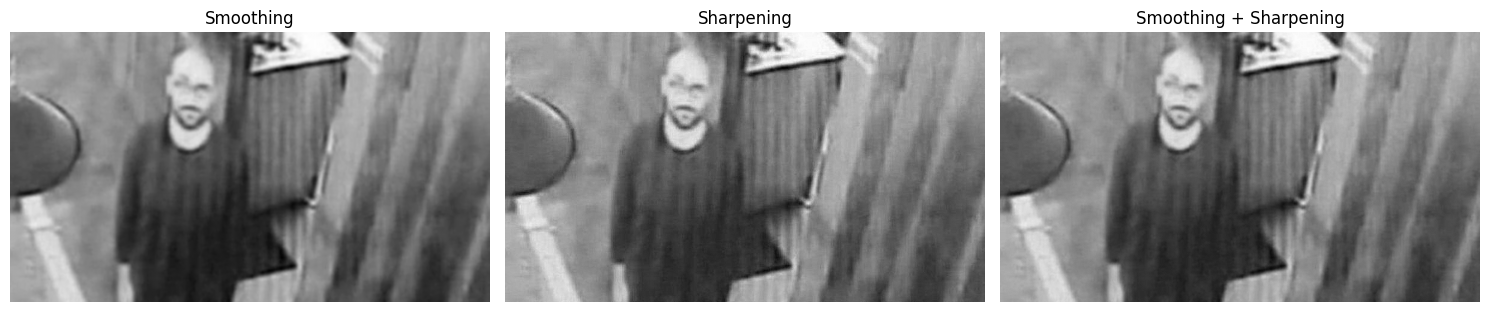

In [23]:
img_bgr = cv2.imread('backup.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

hasil_smooth = convolution(img_gray, k_smooth)
hasil_sharp = convolution(img_gray, k_sharp)
hasil_both = convolution(hasil_smooth, k_sharp)

plt.figure(figsize=(15, 5))
    
plt.subplot(1, 3, 1); plt.imshow(hasil_smooth, cmap='gray')
plt.title('Smoothing'); plt.axis('off')
  
plt.subplot(1, 3, 2); plt.imshow(hasil_sharp, cmap='gray')
plt.title('Sharpening'); plt.axis('off')
    
plt.subplot(1, 3, 3); plt.imshow(hasil_both, cmap='gray')
plt.title('Smoothing + Sharpening'); plt.axis('off')

plt.tight_layout()
plt.show()

## Analisis Perbandingan Metode Perbaikan Citra

Perbaikan citra pada kasus rekaman CCTV melibatkan tiga pendekatan utama dengan karakteristik yang berbeda, yaitu smoothing, sharpening, dan metode kombinasi. Smoothing berfungsi untuk meratakan nilai piksel guna melembutkan gambar dan mengurangi noise dengan cara meratakan intensitas piksel tetangga menggunakan matriks berbobot. Sebaliknya, Sharpening bertujuan meningkatkan kontras pada tepi objek agar detail gambar terlihat lebih tegas melalui pemberian penekanan yang lebih tinggi pada piksel pusat dalam matriks kernel. Untuk mendapatkan hasil maksimal pada citra yang kotor, metode Kombinasi (Smooth + Sharp) dapat diterapkan, di mana proses smoothing dilakukan terlebih dahulu untuk membersihkan bintik pengganggu, baru kemudian dilanjutkan dengan sharpening guna mengembalikan ketajaman objek yang sempat mengabur akibat proses penghalusan sebelumnya.


Dalam manipulasi citra menggunakan teknik Sliding Window, penggunaan filter statistik Mean, Median, dan Modus memberikan dampak visual yang spesifik pada hasil akhirnya. Filter Mean menghasilkan efek gambar yang lebih halus atau kabur karena seluruh nilai dalam jendela dijumlahkan dan dibagi rata, yang meskipun membuat transisi warna menjadi sangat lembut, memiliki kelemahan dalam mengaburkan ketajaman tepi objek. Filter Median dianggap jauh lebih efektif dalam membersihkan noise jenis salt and pepper tanpa merusak ketegasan tepi karena menggunakan nilai tengah dari sekumpulan piksel yang telah diurutkan. Sementara itu, filter Modus memberikan kesan visual seperti poster dengan cara menyeragamkan warna dominan melalui pengambilan nilai piksel yang paling sering muncul dalam area kernel, sehingga area dengan warna serupa akan disatukan menjadi satu warna solid.

In [24]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

### Konvolusi
Fungsi konvolusi tersebut merupakan algoritma dasar untuk pemrosesan citra yang bekerja dengan cara mengalikan matriks kernel terhadap area lokal piksel di seluruh bagian gambar. Penggunaan np.pad dengan mode constant bertujuan untuk menambahkan bingkai di sekeliling citra asli agar koordinat piksel di bagian tepi tetap dapat diproses tanpa mengurangi dimensi output. Di dalam blok perulangan, variabel region mengambil cuplikan piksel sesuai ukuran kernel, lalu dilakukan operasi perkalian elemen serta penjumlahan (np.sum) untuk menghasilkan nilai intensitas baru pada koordinat tersebut. Hasil akhirnya adalah sebuah canvas dalam tipe data float32 yang merepresentasikan citra baru setelah diberi efek tertentu sesuai karakteristik kernel yang digunakan.

In [25]:
def get_edge(img, kx, ky):
    gx = convolution(img, kx)
    gy = convolution(img, ky)
    edge_img = np.abs(gx) + np.abs(gy)
    return edge_img

Fungsi get_edge melakukan deteksi tepi dengan menjumlahkan hasil konvolusi kernel horizontal (G_x) dan vertikal (G_y) untuk mengekstraksi kontur objek. Hasil akhir diperoleh melalui perhitungan |G_x| + |G_y|, yang secara efektif menonjolkan setiap perubahan intensitas piksel dari berbagai arah menjadi garis tepi yang jelas. Metode ini memastikan batas fisik subjek terdeteksi secara menyeluruh tanpa mempedulikan arah perubahan kontrasnya.

In [26]:
    # Definisi Kernel Sobel
sobelX = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float32)

sobelY = np.array([[1, 2, 1], 
                   [0, 0, 0], 
                   [-1, -2, -1]], dtype=np.float32)

    # Definisi Kernel Prewitt
prewittX = np.array([[-1, 0, 1], 
                     [-1, 0, 1], 
                     [-1, 0, 1]], dtype=np.float32)

prewittY = np.array([[1, 1, 1], 
                     [0, 0, 0], 
                     [-1, -1, -1]], dtype=np.float32)

    # Definisi Kernel Roberts
robertsX = np.array([[1, 0], 
                     [0, -1]], dtype=np.float32)
robertsY = np.array([[0, 1], 
                     [-1, 0]], dtype=np.float32)

Kode tersebut mendefinisikan tiga jenis operator deteksi tepi yang umum digunakan dalam pengolahan citra digital. Operator Sobel dan Prewitt menggunakan kernel 3 x 3 untuk menghitung gradien gambar, di mana Sobel memberikan bobot lebih tinggi pada bagian tengah untuk mengurangi sensitivitas terhadap noise. Sementara itu, operator Roberts menggunakan kernel 2 x 2 yang lebih sederhana untuk mendeteksi perubahan intensitas secara diagonal dengan komputasi yang lebih cepat. Ketiga pasangan kernel ini (X dan Y) berfungsi untuk menangkap fitur tepi pada arah horizontal dan vertikal secara spesifik.

### Menampilkan Hasil Penggunaan Operator Sobel, Prewitt dan Roberts beserta Gabungannya

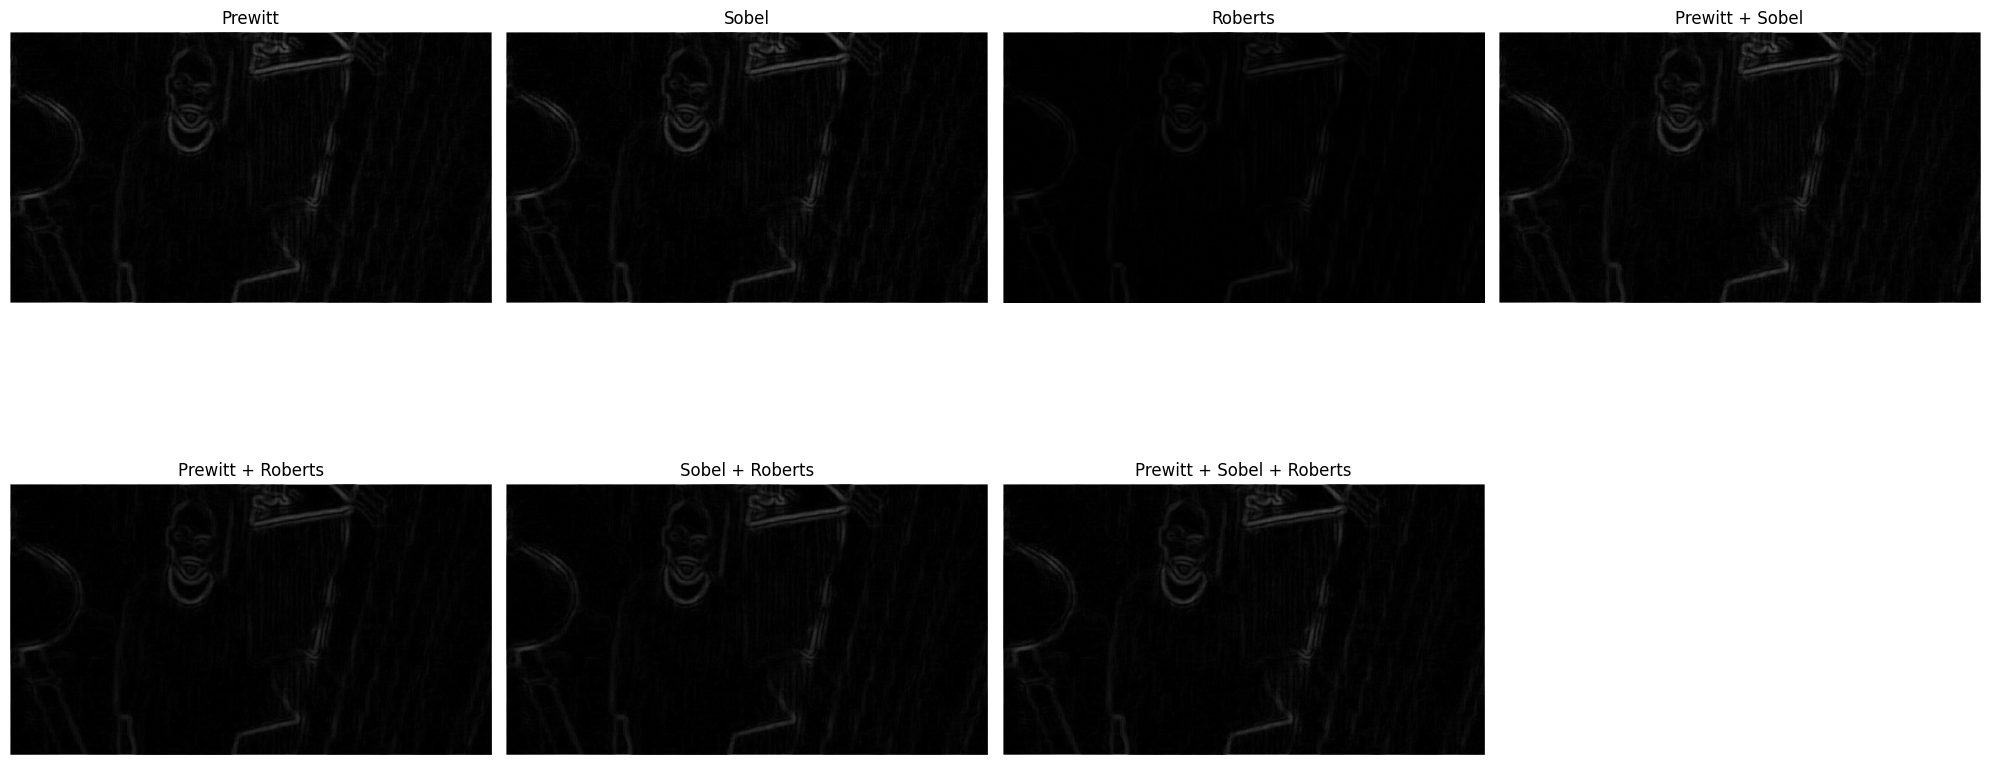

In [27]:
img_bgr = cv2.imread('backup.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

edge_prewitt = get_edge(img_gray, prewittX, prewittY)
edge_sobel = get_edge(img_gray, sobelX, sobelY)
edge_roberts = get_edge(img_gray, robertsX, robertsY)

res_p_s = edge_prewitt + edge_sobel
res_p_r = edge_prewitt + edge_roberts
res_s_r = edge_sobel + edge_roberts
res_all = edge_prewitt + edge_sobel + edge_roberts

# 4. Fungsi Normalisasi
def normalize(img):
    if np.max(img) > 0:
        img = img * 255.0 / np.max(img)
    return np.clip(img, 0, 255).astype(np.uint8) 

titles = ['Prewitt', 'Sobel', 'Roberts', 'Prewitt + Sobel', 
          'Prewitt + Roberts', 'Sobel + Roberts', 'Prewitt + Sobel + Roberts']
images = [edge_prewitt, edge_sobel, edge_roberts, res_p_s, 
          res_p_r, res_s_r, res_all]

plt.figure(figsize=(20, 10))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    
    plt.imshow(normalize(images[i]), cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Analisis Operator Deteksi Tepi
Operator deteksi tepi seperti Sobel, Prewitt, dan Roberts digunakan untuk mengidentifikasi area pada citra di mana terjadi perubahan intensitas cahaya yang drastis, yang biasanya menandakan batas atau tepi suatu objek. Operator Sobel dan Prewitt bekerja dengan melakukan konvolusi citra menggunakan kernel berukuran 3x3 untuk menghitung gradien secara horizontal dan vertikal, di mana Sobel memberikan penekanan lebih pada piksel pusat untuk mengurangi sensitivitas terhadap noise. Sementara itu, operator Roberts menggunakan kernel yang lebih kecil (2x2) dan bekerja secara diagonal, menjadikannya sangat efisien untuk mendeteksi tepi yang sangat tajam pada citra dengan tingkat noise rendah.

Kombinasi dari operator-operator tersebut dilakukan dengan menjumlahkan hasil deteksi dari masing-masing metode sebelum dilakukan proses normalisasi ke rentang nilai 0-255. Penjumlahan ini bertujuan untuk memperkuat visualisasi tepi objek karena setiap operator memiliki karakteristik unik dalam menonjolkan fitur tertentu; misalnya, kombinasi Prewitt + Sobel dapat menghasilkan garis tepi yang lebih tebal dan jelas dibandingkan jika digunakan secara tunggal. Dengan menjabarkan hasil dari berbagai kombinasi seperti Prewitt + Sobel + Roberts, informasi tepi yang tertangkap menjadi lebih kaya dan komprehensif, sangat berguna dalam analisis citra CCTV untuk memperjelas siluet subjek atau detail latar belakang.

### Menampilkan Hasil Tresholds

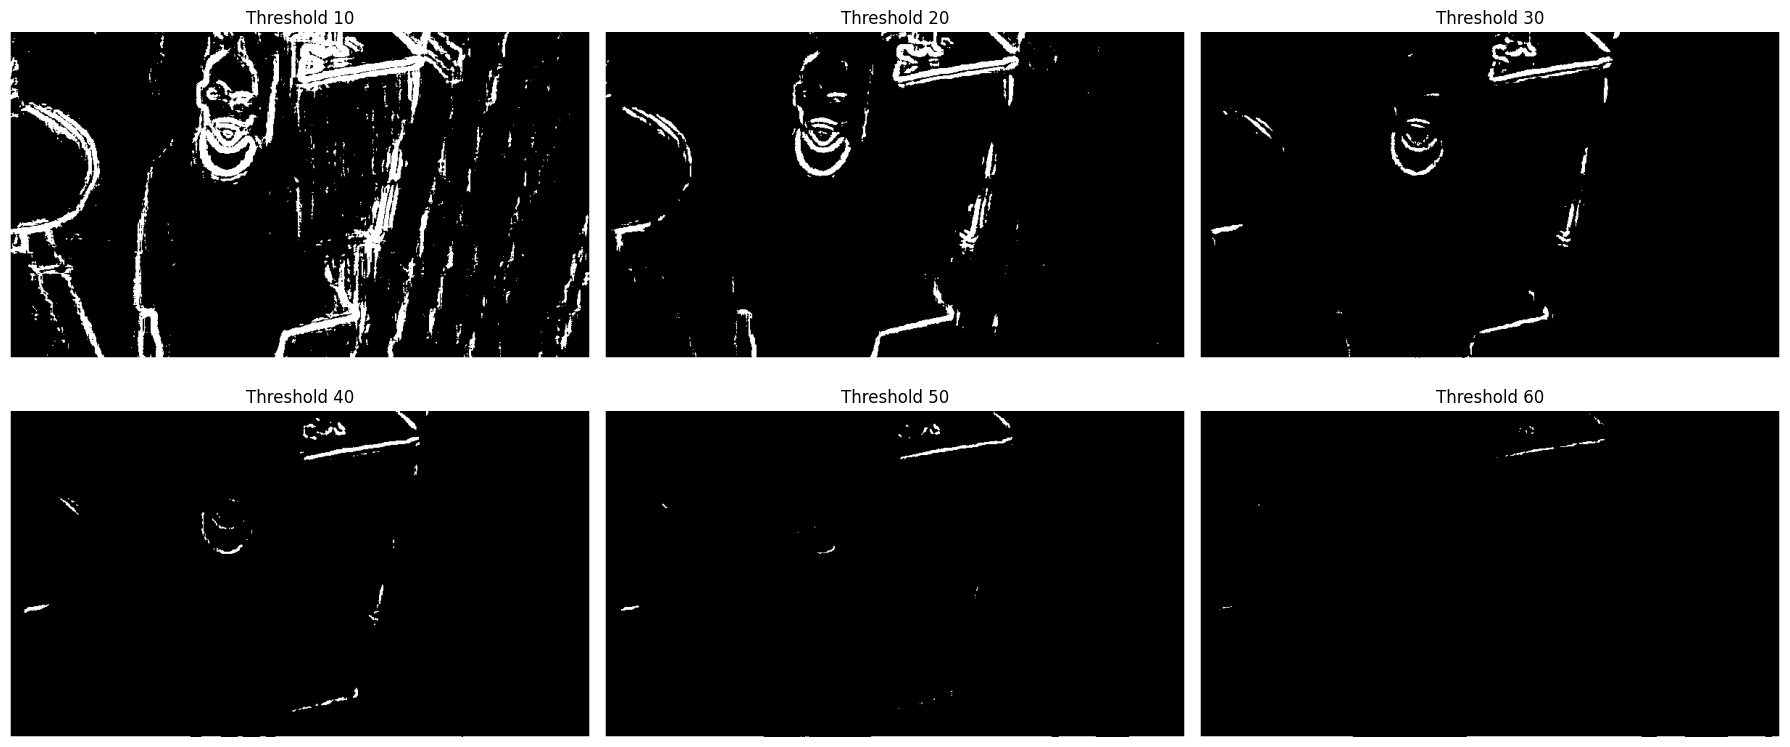

In [28]:

def get_edge_data(img, kx, ky):
    gx = convolution(img, kx) #
    gy = convolution(img, ky) #
    return np.abs(gx) + np.abs(gy) #

img_bgr = cv2.imread('backup.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

edge_s = get_edge_data(img_gray, sobelX, sobelY)
edge_p = get_edge_data(img_gray, prewittX, prewittY)
edge_r = get_edge_data(img_gray, robertsX, robertsY)

combined_edge = edge_s + edge_p + edge_r

# Normalisasi ke 0-255
if np.max(combined_edge) > 0:
    combined_edge = (combined_edge / np.max(combined_edge)) * 255

thresholds = [10, 20, 30, 40, 50, 60]
    
plt.figure(figsize=(18, 8))
for i, t in enumerate(thresholds):
    binary = np.zeros_like(combined_edge, dtype=np.uint8)
    binary[combined_edge > t] = 255
        
    plt.subplot(2, 3, i+1)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Threshold {t}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Analisis Penggunaan Tresholding
Penggunaan thresholding berfungsi sebagai segmentasi untuk memisahkan objek tepi dari latar belakang berdasarkan intensitas piksel hasil deteksi. Perbedaan mencoloknya adalah threshold rendah (10-20) menampilkan detail tepi yang sangat lengkap namun dipenuhi noise, sedangkan threshold tinggi (50-60) menghasilkan citra yang bersih tetapi berisiko memutus garis tepi objek yang penting.

Untuk kasus CCTV ini, nilai 30 atau 40 adalah yang paling bagus karena memberikan keseimbangan terbaik antara keutuhan siluet orang dan kebersihan latar belakang. Analisis dari rentang 10-60 menunjukkan bahwa semakin tinggi nilai ambang batasnya, gambar akan semakin kontras dan fokus hanya pada fitur yang paling menonjol sehingga memudahkan identifikasi subjek tanpa gangguan detail yang tidak relevan.

### Menampilkan Hasil

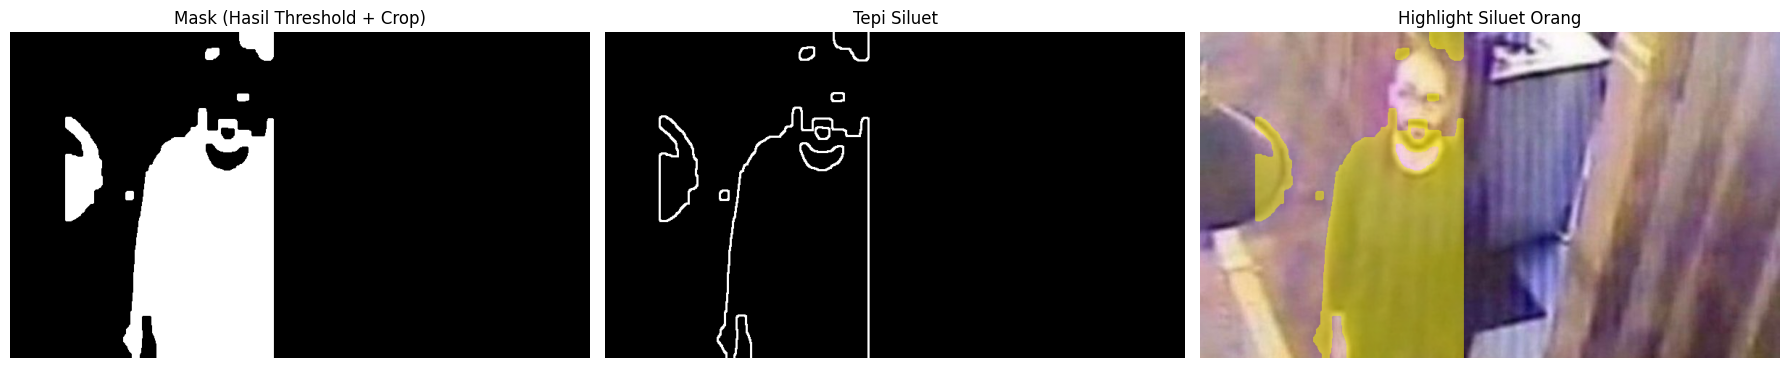

In [39]:
img_bgr = cv2.imread('backup.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img_gray, 120, 255, cv2.THRESH_BINARY_INV)
    
    
mask_final = np.zeros_like(mask)
h, w = mask.shape
mask_final[5:h-5, 80:360] = mask[5:h-5, 80:360]
    
kernel = np.ones((9,9), np.uint8)

mask_final = cv2.dilate(mask_final, kernel, iterations=1)
   
mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_CLOSE, kernel)
 
mask_final = cv2.GaussianBlur(mask_final, (5, 5), 0)
_, mask_final = cv2.threshold(mask_final, 127, 255, cv2.THRESH_BINARY)

tepi_siluet = cv2.Canny(mask_final, 100, 200)
tepi_siluet = cv2.dilate(tepi_siluet, np.ones((3,3), np.uint8), iterations=1)

overlay = img_rgb.copy()
overlay[mask_final == 255] = [255, 255, 0] 
    
highlight_final = cv2.addWeighted(overlay, 0.5, img_rgb, 0.5, 0)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mask_final, cmap='gray')
plt.title('Mask (Hasil Threshold + Crop)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(tepi_siluet, cmap='gray')
plt.title('Tepi Siluet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(highlight_final)
plt.title('Highlight Siluet Orang')
plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
def median_filter(img, size):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img)
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.median(region)
    return canvas

Fungsi median_filter merupakan teknik pembersihan citra yang bekerja dengan cara mengganti setiap nilai piksel menggunakan nilai median dari area lokal di sekelilingnya. Berbeda dengan filter rata-rata, penggunaan fungsi np.median sangat efektif dalam menghilangkan salt-and-pepper noise tanpa mengaburkan detail tepi objek secara signifikan

### Menampilkan Gambar Hasil

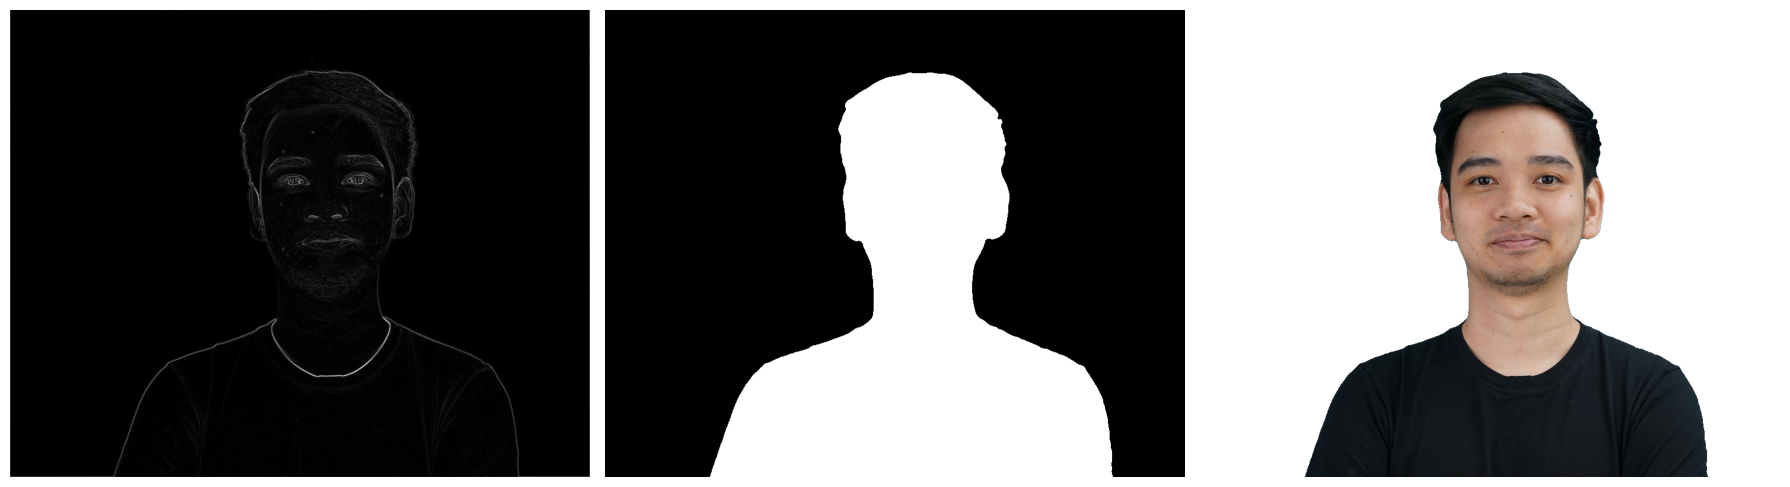

In [31]:
img_bgr = cv2.imread('david.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

sobelX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobelY = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
edge = np.abs(convolution(img_gray, sobelX)) + np.abs(convolution(img_gray, sobelY))
edge = (edge / np.max(edge) * 255).astype(np.uint8)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
R = img_rgb[:,:,0].astype(np.int16)
G = img_rgb[:,:,1].astype(np.int16)
B = img_rgb[:,:,2].astype(np.int16)
    
mask = np.zeros_like(img_gray)
mask[(R - G > -20)] = 255 
mask_clean = median_filter(mask, 9)


result = img_rgb.copy()
result[mask_clean == 0] = [255, 255, 255]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(edge, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_clean, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.axis('off')

plt.tight_layout()
plt.show()

##  proses perubahan dari citra awal hinggake bagian penghilangan background
Proses perubahan citra diawali dengan mengubah citra asli david.jpg menjadi format Grayscale untuk menyederhanakan data piksel menjadi satu saluran intensitas, yang kemudian diproses melalui tahap Deteksi Tepi menggunakan operator konvolusi untuk menonjolkan batas fisik subjek seperti wajah dan pakaian. Setelah itu, dilakukan pembuatan Mask Background dengan memanfaatkan perbandingan nilai kanal RGB dari citra asli guna mengidentifikasi latar belakang berwarna toska secara spesifik, lalu dirapikan menggunakan median filtering untuk menghilangkan bintik pengganggu (noise). Tahap terakhir adalah Penghilangan Background, di mana masker tersebut digunakan sebagai acuan untuk mengubah seluruh piksel latar belakang menjadi warna putih murni sembari tetap mempertahankan detail dan warna asli pada subjek utama.

## Kesimpulan
Integrasi antara perbaikan kualitas citra dan deteksi tepi berfungsi untuk mentransformasi rekaman CCTV mentah yang kabur menjadi informasi visual yang lebih tegas dan mudah diidentifikasi. Tahap perbaikan melalui filter median dan operasi berperan krusial dalam mereduksi gangguan visual (noise) serta memperkuat kepadatan siluet subjek agar bentuknya tetap utuh meski terpapar pencahayaan yang tidak konsisten. Sementara itu, penerapan deteksi tepi menggunakan operator gradien memungkinkan ekstraksi garis kontur secara presisi guna memisahkan profil fisik orang dari latar belakangnya. Secara keseluruhan, rangkaian proses ini sangat vital dalam pengolahan citra digital untuk mempertajam detail objek yang diperlukan dalam sistem keamanan, pelacakan otomatis, maupun identifikasi identitas di lingkungan.